Cargando datos y extrayendo 102 features...
  Features retenidas tras corte 0.0013: 69

Iniciando búsqueda de hiperparámetros...
  Esto puede tardar varios minutos — hay 48 combinaciones.

   n_est |  max_feat | min_leaf |  max_depth |   Train |     Val
  ─────────────────────────────────────────────────────────────────
     700 |      sqrt |        2 |       None | 0.9993 | 0.2388  ← MEJOR

  ✔ Mejor configuración encontrada:
     n_estimators         = 700
     max_features         = sqrt
     min_samples_leaf     = 2
     max_depth            = None
  ✔ Mejor Val Accuracy : 0.2388
  ✔ Baseline anterior  : 0.2361
  ✔ Delta              : +0.0027


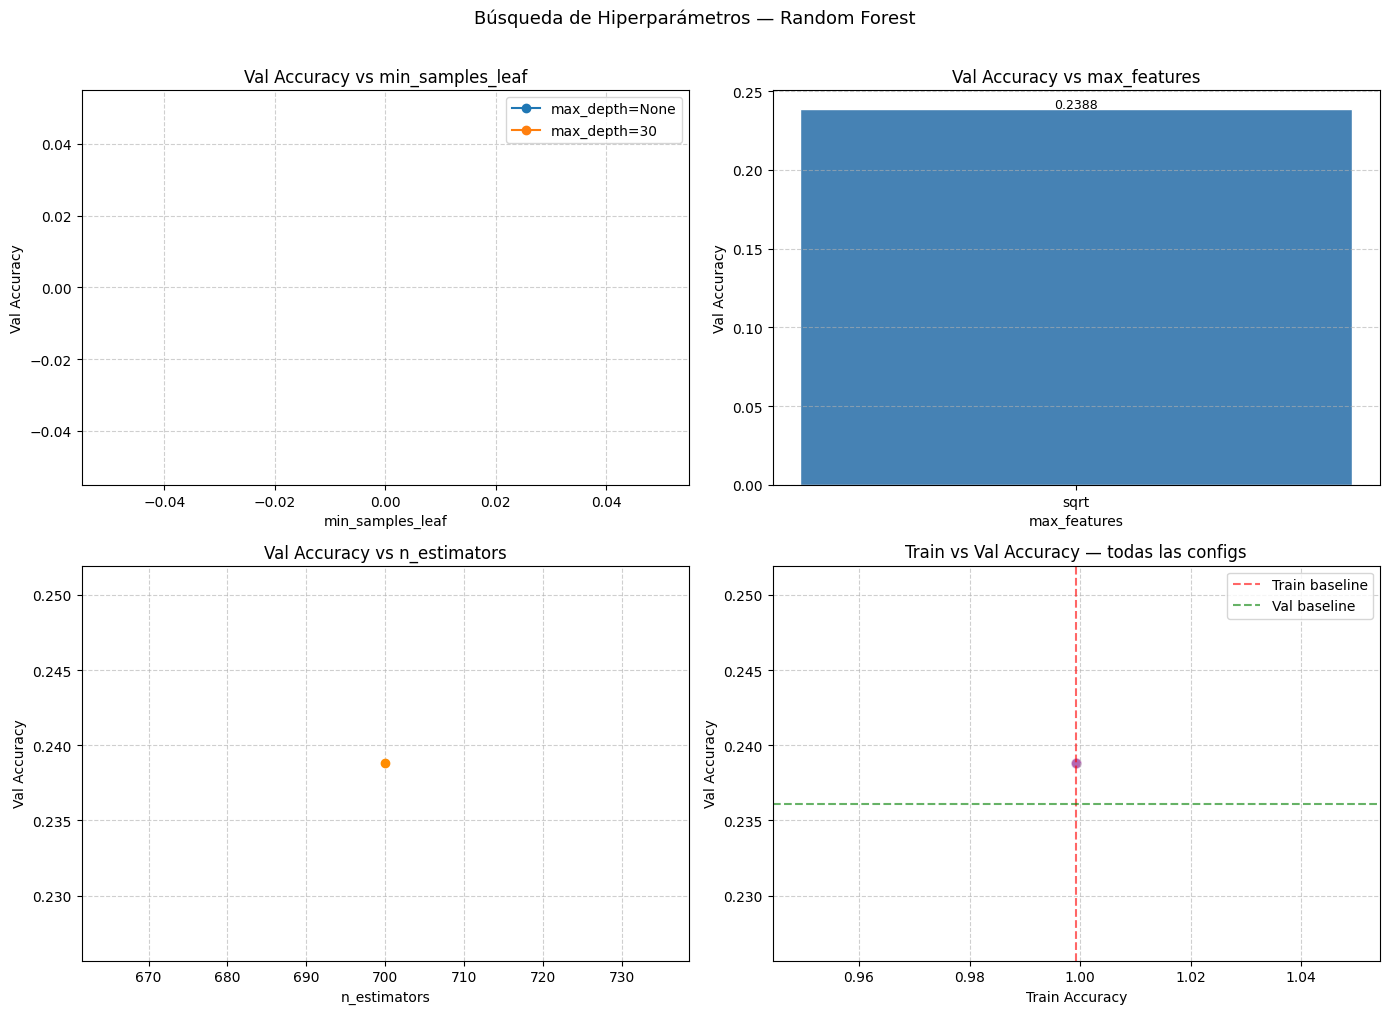

  Gráfica guardada en rf_hyperparameter_search.png

Entrenando modelo final con la mejor configuración...
  Train: 0.9993 | Val: 0.2388

Reentrenando sobre el 100% del dataset...
  ✔ rf_hiperparametros.csv generado (3490 filas)

  ══════════════════════════════════════════
  RESUMEN FINAL
  ══════════════════════════════════════════
  Features utilizadas  : 69
  n_estimators         : 700
  max_features         : sqrt
  min_samples_leaf     : 2
  max_depth            : None
  Val Accuracy         : 0.2388
  Train Accuracy       : 0.9993
  Delta vs baseline    : +0.0027
  ══════════════════════════════════════════


In [2]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import itertools

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────────────────────
# 1. DEFINICIÓN DE SÍMBOLOS Y EXPRESIONES REGULARES
# ─────────────────────────────────────────────────────────────────────────────
SIMBOLOS_FRECUENTES = [
    ',', '.', '-', '^', ':', ';', "'", '*', '(', '»',
    '/', '?', ')', '¿', '>', '«', '¡', '!', '|', '&',
    '¬', '<', '£', '"', '—', '$', '•', '\\', 'ſ', '[',
    '=', '\u2018', ']', '%', '■', '\u201c', '©', '}', '€', '{',
    '°', '„', '#', '+', '®', '\u201d', '\u2019', '_'
]
SIMBOLOS_MEDIEVALES = [
    'ꝛ', '§', '~', '⁊', 'ẽ', 'ũ', '⸗', 'õ', '™', 'ã', '♦'
]
TODOS_SIMBOLOS = SIMBOLOS_FRECUENTES + SIMBOLOS_MEDIEVALES

def nombre_columna(simbolo):
    nombres = {
        ',': 'sim_coma', '.': 'sim_punto', '-': 'sim_guion', '^': 'sim_caret',
        ':': 'sim_dos_puntos', ';': 'sim_punto_coma', "'": 'sim_apostrofe', '*': 'sim_asterisco',
        '(': 'sim_paren_abrir', '»': 'sim_guillemet_der', '/': 'sim_barra', '?': 'sim_interrogacion',
        ')': 'sim_paren_cerrar', '¿': 'sim_interrogacion_es', '>': 'sim_mayor', '«': 'sim_guillemet_izq',
        '¡': 'sim_exclamacion_es', '!': 'sim_exclamacion', '|': 'sim_barra_vertical', '&': 'sim_ampersand',
        '¬': 'sim_silabeo', '<': 'sim_menor', '£': 'sim_libra', '"': 'sim_comilla_doble',
        '—': 'sim_raya', '$': 'sim_dolar', '•': 'sim_viñeta', '\\': 'sim_barra_inversa',
        'ſ': 'sim_s_larga', '[': 'sim_corchete_abrir', '=': 'sim_igual', '\u2018': 'sim_comilla_izq',
        ']': 'sim_corchete_cerrar', '%': 'sim_porcentaje', '■': 'sim_cuadrado', '\u201c': 'sim_comilla_doble_izq',
        '©': 'sim_copyright', '}': 'sim_llave_cerrar', '€': 'sim_euro', '{': 'sim_llave_abrir',
        '°': 'sim_grado', '„': 'sim_comilla_baja', '#': 'sim_almohadilla', '+': 'sim_mas',
        '®': 'sim_marca_reg', '\u201d': 'sim_comilla_doble_der', '\u2019': 'sim_comilla_der', '_': 'sim_guion_bajo',
        'ꝛ': 'sim_r_medieval', '§': 'sim_seccion', '~': 'sim_tilde', '⁊': 'sim_tironian_et',
        'ẽ': 'sim_e_tilde', 'ũ': 'sim_u_tilde', '⸗': 'sim_guion_doble', 'õ': 'sim_o_tilde',
        '™': 'sim_trademark', 'ã': 'sim_a_tilde', '♦': 'sim_rombo',
    }
    return nombres.get(simbolo, f'sim_{ord(simbolo)}')

COLUMNAS_SIMBOLOS = [nombre_columna(s) for s in TODOS_SIMBOLOS]

PALABRAS_ARCAICAS = re.compile(
    r'\b(?:efto|efta|eftos|eftas|dize|diziendo|dixo|hazer|fazer|dezir|cofa|'
    r'cofas|mifmo|mifma|afsi|affi|tambien|efpañ\w*|efcriv\w*|efcrib\w*|'
    r'vueftra|vueflra|vueftro|merced|feñor|feñora|ombre|fobre|fiempre|'
    r'defpues|aunque|donde|quando|porque|agora|anfi|afi|anſi)\b', re.IGNORECASE
)
PALABRAS_LATINAS = re.compile(
    r'\b\w+(?:ibus|orum|arum|onis|atis|ens|antis|um|us|is|ae)\b', re.IGNORECASE
)
NUMEROS_ROMANOS = re.compile(
    r'\b(M{0,4}(CM|CD|D?C{0,3})(XC|XL|L?X{0,3})(IX|IV|V?I{0,3}))\b',
    re.IGNORECASE
)
ABREVIATURAS      = re.compile(r'\b[a-záéíóúüñ]{1,5}\.')
U_COMO_V          = re.compile(r'\bv[aeiouáéíóú]', re.IGNORECASE)
J_POR_X           = re.compile(
    r'\b(?:di[jx]o|ba[jx]o|me[jx]or|de[jx]ar|de[jx]ó|hi[jx]o|'
    r'mu[jx]er|tra[jx]|[jx]unto|[jx]ugar|[jx]uzgar|[jx]uicio)\b',
    re.IGNORECASE
)
MAYUS_MID_ORACION = re.compile(r'(?<![.!?\n])\s+[A-ZÁÉÍÓÚÜÑ][a-záéíóúüñ]{2,}')
CONECTORES_MODERNOS = re.compile(
    r'\b(?:sin embargo|no obstante|es decir|por lo tanto|en consecuencia|'
    r'por consiguiente|a pesar de|dado que|puesto que|ya que|'
    r'en efecto|de hecho|por otro lado|en cambio|así pues)\b',
    re.IGNORECASE
)
VERBOS_ARCAICOS   = re.compile(
    r'\b\w+(?:edes|ades|istes|ábades|íades|áredes|éredes|íredes)\b',
    re.IGNORECASE
)
CHARS_AISLADOS    = re.compile(r'(?<!\w)\b([b-df-hj-np-tv-zB-DF-HJ-NP-TV-Z])\b(?!\w)')
F_INICIAL         = re.compile(
    r'\b(?:fab\w+|faz\w+|fij\w+|ferm\w+|ferr\w+|fiel\w+|fil\w+|'
    r'fin\w+|fue\w+|fuy\w+|fall\w+|fal\w+|fam\w+|far\w+|fat\w+|'
    r'fech\w+|fend\w+|ferv\w+|fest\w+|fid\w+|fog\w+|folg\w+|fond\w+|'
    r'font\w+|forc\w+|forn\w+|forr\w+|foy\w+|fuert\w+|fug\w+)\b',
    re.IGNORECASE
)


# ─────────────────────────────────────────────────────────────────────────────
# 2. FUNCIÓN DE EXTRACCIÓN (102 FEATURES)
# ─────────────────────────────────────────────────────────────────────────────
def extraer_features(texto):
    if not isinstance(texto, str) or len(texto) == 0:
        return [0] * (43 + len(TODOS_SIMBOLOS))

    palabras_lista  = texto.split()
    n_palabras      = max(len(palabras_lista), 1)
    n_caracteres    = len(texto)
    n_espacios      = max(texto.count(' '), 1)
    n_saltos_linea  = texto.count('\n')
    total_letras    = max(len(re.findall(r'[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', texto)), 1)
    texto_lower     = texto.lower()

    caracteres                = n_caracteres / n_palabras
    palabras                  = n_palabras
    simbolos                  = len(re.findall(r'[^a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ\s]', texto)) / n_palabras
    mayusculas_count          = sum(1 for c in texto if c.isupper())
    mayusculas                = mayusculas_count / n_palabras
    oraciones                 = max(len(re.findall(r'[.!?]+', texto)), 1) / n_palabras
    longitud_promedio_palabra = np.mean([len(w) for w in palabras_lista])
    ratio_doble_espacio       = len(re.findall(r' {2,}', texto)) / n_espacios
    palabras_arcaicas_n       = len(PALABRAS_ARCAICAS.findall(texto_lower)) / n_palabras
    palabras_latinas_n        = len(PALABRAS_LATINAS.findall(texto_lower)) / n_palabras
    vocales_acentuadas_count  = len(re.findall(r'[áéíóúÁÉÍÓÚ]', texto))
    ratio_vocales_acentuadas  = vocales_acentuadas_count / total_letras
    signos_es                 = len(re.findall(r'[¡¿]', texto)) / n_palabras
    comillas_angulares        = len(re.findall(r'[«»]', texto)) / n_palabras
    guiones                   = len(re.findall(r'-', texto)) / n_palabras
    ruido_ocr                 = len(re.findall(r'[\^*|&£><@#~\\`{}[\]=]', texto)) / n_palabras

    frecuencias = Counter(texto)
    entropia = -sum((f / n_caracteres) * math.log2(f / n_caracteres)
                    for f in frecuencias.values()) if n_caracteres > 0 else 0
    diversidad_lexica     = len(set(palabras_lista)) / n_palabras
    ratio_palabras_cortas = sum(1 for w in palabras_lista if len(w) <= 3) / n_palabras

    espacios_por_palabra    = texto.count(' ') / n_palabras
    saltos_por_palabra      = n_saltos_linea / n_palabras
    tabs_por_palabra        = texto.count('\t') / n_palabras
    longitud_promedio_linea = n_caracteres / (n_saltos_linea + 1)
    cortes_guion_fin_linea  = len(re.findall(r'-\s*\n', texto)) / n_palabras
    digitos_por_palabra     = sum(1 for c in texto if c.isdigit()) / n_palabras

    ratio_numeros_romanos = len([m for m in NUMEROS_ROMANOS.findall(texto) if len(m[0]) >= 2]) / n_palabras
    ratio_abreviaturas    = len(ABREVIATURAS.findall(texto_lower)) / n_palabras
    ratio_u_como_v        = len(U_COMO_V.findall(texto_lower)) / n_palabras
    ratio_j_por_x         = len(J_POR_X.findall(texto_lower)) / n_palabras

    ratio_mayus_mid   = len(MAYUS_MID_ORACION.findall(texto)) / n_palabras
    densidad_parrafos = (len(re.findall(r'\n\s*\n', texto)) + 1) / n_palabras

    ratio_conectores_modernos = len(CONECTORES_MODERNOS.findall(texto_lower)) / n_palabras
    ratio_verbos_arcaicos     = len(VERBOS_ARCAICOS.findall(texto_lower)) / n_palabras
    conteo_e   = len(re.findall(r'\be\b', texto_lower))
    conteo_y   = len(re.findall(r'\by\b', texto_lower))
    ratio_e_vs_y    = conteo_e / (conteo_e + conteo_y + 1)
    conteo_non = len(re.findall(r'\bnon\b', texto_lower))
    conteo_no  = len(re.findall(r'\bno\b', texto_lower))
    ratio_non_vs_no = conteo_non / (conteo_non + conteo_no + 1)
    ratio_art_la    = len(re.findall(r'\bla\b', texto_lower)) / n_palabras

    ratio_chars_aislados     = len(CHARS_AISLADOS.findall(texto)) / n_palabras
    ratio_grupos_consonantes = len(re.findall(
        r'[bcdfghjklmnpqrstvwxyzBCDFGHJKLMNPQRSTVWXYZ]{3,}', texto
    )) / n_palabras

    freq_palabras = Counter(palabras_lista)
    ratio_hapax   = sum(1 for f in freq_palabras.values() if f == 1) / n_palabras
    ratio_palabras_largas = sum(1 for w in palabras_lista if len(w) >= 8) / n_palabras
    oraciones_lista        = re.split(r'[.!?]+', texto)
    n_oraciones            = max(len(oraciones_lista), 1)
    ratio_oraciones_largas = sum(1 for o in oraciones_lista if len(o.split()) > 30) / n_oraciones
    ratio_tildes_sobre_mayusculas = vocales_acentuadas_count / max(mayusculas_count, 1)
    ratio_q         = texto_lower.count('q') / total_letras
    ratio_f_inicial = len(F_INICIAL.findall(texto_lower)) / n_palabras
    conteo_i_conj   = len(re.findall(r'\bi\b', texto_lower))
    conteo_y_conj   = len(re.findall(r'\by\b', texto_lower))
    ratio_i_vs_y    = conteo_i_conj / (conteo_i_conj + conteo_y_conj + 1)

    features_estilo = [
        caracteres, palabras, simbolos, mayusculas,
        oraciones, longitud_promedio_palabra,
        ratio_doble_espacio, palabras_arcaicas_n, palabras_latinas_n,
        ratio_vocales_acentuadas, signos_es, comillas_angulares,
        guiones, ruido_ocr,
        entropia, diversidad_lexica, ratio_palabras_cortas,
        espacios_por_palabra, saltos_por_palabra, tabs_por_palabra,
        longitud_promedio_linea, cortes_guion_fin_linea, digitos_por_palabra,
        ratio_numeros_romanos, ratio_abreviaturas,
        ratio_u_como_v, ratio_j_por_x,
        ratio_mayus_mid, densidad_parrafos,
        ratio_conectores_modernos, ratio_verbos_arcaicos,
        ratio_e_vs_y, ratio_non_vs_no, ratio_art_la,
        ratio_chars_aislados, ratio_grupos_consonantes,
        ratio_hapax, ratio_palabras_largas, ratio_oraciones_largas,
        ratio_tildes_sobre_mayusculas, ratio_q, ratio_f_inicial, ratio_i_vs_y,
    ]

    ratios_simbolos = [texto.count(s) / n_palabras for s in TODOS_SIMBOLOS]
    return features_estilo + ratios_simbolos


FEATURE_NAMES = [
    'caracteres', 'palabras', 'simbolos', 'mayusculas', 'oraciones',
    'longitud_promedio_palabra', 'ratio_doble_espacio', 'palabras_arcaicas',
    'palabras_latinas', 'ratio_vocales_acentuadas', 'signos_es',
    'comillas_angulares', 'guiones', 'ruido_ocr',
    'entropia', 'diversidad_lexica', 'ratio_palabras_cortas',
    'espacios_por_palabra', 'saltos_por_palabra', 'tabs_por_palabra',
    'longitud_promedio_linea', 'cortes_guion_fin_linea', 'digitos_por_palabra',
    'ratio_numeros_romanos', 'ratio_abreviaturas',
    'ratio_u_como_v', 'ratio_j_por_x',
    'ratio_mayus_mid', 'densidad_parrafos',
    'ratio_conectores_modernos', 'ratio_verbos_arcaicos',
    'ratio_e_vs_y', 'ratio_non_vs_no', 'ratio_art_la',
    'ratio_chars_aislados', 'ratio_grupos_consonantes',
    'ratio_hapax', 'ratio_palabras_largas', 'ratio_oraciones_largas',
    'ratio_tildes_sobre_mayusculas', 'ratio_q', 'ratio_f_inicial', 'ratio_i_vs_y',
] + COLUMNAS_SIMBOLOS

N_FEATURES_ESTILO = 43
assert len(FEATURE_NAMES) == N_FEATURES_ESTILO + len(TODOS_SIMBOLOS)


# ─────────────────────────────────────────────────────────────────────────────
# 3. CARGA, EXTRACCIÓN Y SELECCIÓN DE FEATURES (umbral 0.0013)
# ─────────────────────────────────────────────────────────────────────────────
print(f"Cargando datos y extrayendo {N_FEATURES_ESTILO + len(TODOS_SIMBOLOS)} features...")
data      = pd.read_csv("../../data/train.csv")
data_test = pd.read_csv("../../data/eval.csv")

feat_train = np.array(data["text"].apply(extraer_features).tolist(),      dtype=np.float32)
feat_test  = np.array(data_test["text"].apply(extraer_features).tolist(), dtype=np.float32)

y = data["decade"]

X_train, X_val, y_train, y_val = train_test_split(
    feat_train, y, test_size=0.2, random_state=42, stratify=y
)

# Selección de features con el mismo proceso del modelo ganador
UMBRAL = 0.0013

scaler_sel    = StandardScaler()
X_sel_s       = scaler_sel.fit_transform(X_train)
rf_sel        = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                                        min_samples_leaf=2, class_weight='balanced',
                                        random_state=42, n_jobs=-1)
rf_sel.fit(X_sel_s, y_train)

imp_df = pd.DataFrame({'feature': FEATURE_NAMES,
                        'importancia': rf_sel.feature_importances_}
                      ).sort_values('importancia', ascending=False)

features_retenidas = imp_df[imp_df['importancia'] >= UMBRAL]['feature'].tolist()
indices_retenidos  = [FEATURE_NAMES.index(f) for f in features_retenidas]

X_train_r = X_train[:, indices_retenidos]
X_val_r   = X_val[:,   indices_retenidos]
feat_train_r = feat_train[:, indices_retenidos]
feat_test_r  = feat_test[:,  indices_retenidos]

print(f"  Features retenidas tras corte {UMBRAL}: {len(features_retenidas)}")

scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_train_r)
X_val_s = scaler.transform(X_val_r)


# ─────────────────────────────────────────────────────────────────────────────
# 4. BÚSQUEDA DE HIPERPARÁMETROS (Grid Search manual)
#
#    Los 4 hiperparámetros con mayor impacto en este problema:
#
#    n_estimators      — más árboles = más estabilidad (rendimientos decrecientes)
#    max_features      — diversidad entre árboles (sqrt ≈ 8, log2 ≈ 6, 0.3 ≈ 21)
#    min_samples_leaf  — regularización: ataca el overfitting train=0.9993 vs val=0.2361
#    max_depth         — otra forma de regularización, limita profundidad de árboles
# ─────────────────────────────────────────────────────────────────────────────
print("\nIniciando búsqueda de hiperparámetros...")
print("  Esto puede tardar varios minutos — hay 48 combinaciones.\n")

grid = {
    'n_estimators':     [700],
    'max_features':     ['sqrt'],          # ya confirmado como mejor
    'min_samples_leaf': [2],               # ya confirmado como mejor
    'max_depth':        [None],            # ya confirmado como mejor
}

combinaciones = list(itertools.product(
    grid['n_estimators'],
    grid['max_features'],
    grid['min_samples_leaf'],
    grid['max_depth'],
))

print(f"  {'n_est':>6} | {'max_feat':>9} | {'min_leaf':>8} | {'max_depth':>10} | {'Train':>7} | {'Val':>7}")
print("  " + "─" * 65)

resultados     = []
mejor_acc_val  = 0
mejor_config   = {}

for n_est, max_feat, min_leaf, max_dep in combinaciones:
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_features=max_feat,
        min_samples_leaf=min_leaf,
        max_depth=max_dep,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr_s, y_train)
    acc_tr  = accuracy_score(y_train, rf.predict(X_tr_s))
    acc_val = accuracy_score(y_val,   rf.predict(X_val_s))

    dep_str  = str(max_dep) if max_dep else "None"
    feat_str = str(max_feat)
    marca    = "  ← MEJOR" if acc_val > mejor_acc_val else ""

    print(f"  {n_est:>6} | {feat_str:>9} | {min_leaf:>8} | {dep_str:>10} | {acc_tr:.4f} | {acc_val:.4f}{marca}")

    resultados.append({
        'n_estimators': n_est, 'max_features': max_feat,
        'min_samples_leaf': min_leaf, 'max_depth': max_dep,
        'acc_train': acc_tr, 'acc_val': acc_val
    })

    if acc_val > mejor_acc_val:
        mejor_acc_val = acc_val
        mejor_config  = {
            'n_estimators': n_est, 'max_features': max_feat,
            'min_samples_leaf': min_leaf, 'max_depth': max_dep
        }

print(f"\n  ✔ Mejor configuración encontrada:")
for k, v in mejor_config.items():
    print(f"     {k:<20} = {v}")
print(f"  ✔ Mejor Val Accuracy : {mejor_acc_val:.4f}")
print(f"  ✔ Baseline anterior  : 0.2361")
delta = mejor_acc_val - 0.2361
print(f"  ✔ Delta              : {delta:+.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# 5. GRÁFICAS DE RESULTADOS
# ─────────────────────────────────────────────────────────────────────────────
res_df = pd.DataFrame(resultados)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Val accuracy por min_samples_leaf
for depth in [None, 30]:
    sub = res_df[res_df['max_depth'] == depth]
    by_leaf = sub.groupby('min_samples_leaf')['acc_val'].max()
    label   = f'max_depth={depth}'
    axes[0,0].plot(by_leaf.index, by_leaf.values, marker='o', label=label)
axes[0,0].set_title("Val Accuracy vs min_samples_leaf")
axes[0,0].set_xlabel("min_samples_leaf")
axes[0,0].set_ylabel("Val Accuracy")
axes[0,0].legend()
axes[0,0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Val accuracy por max_features
feat_order = ['sqrt', 'log2', 0.4]
by_feat    = res_df.groupby('max_features')['acc_val'].max().reindex(
    [str(f) for f in feat_order] if False else feat_order
)
by_feat = res_df.groupby('max_features')['acc_val'].max()
axes[0,1].bar([str(f) for f in by_feat.index], by_feat.values,
              color='steelblue', edgecolor='white')
axes[0,1].set_title("Val Accuracy vs max_features")
axes[0,1].set_xlabel("max_features")
axes[0,1].set_ylabel("Val Accuracy")
axes[0,1].grid(axis='y', linestyle='--', alpha=0.6)
for i, (feat, val) in enumerate(by_feat.items()):
    axes[0,1].text(i, val + 0.0002, f'{val:.4f}', ha='center', fontsize=9)

# Plot 3: Val accuracy por n_estimators
by_nest = res_df.groupby('n_estimators')['acc_val'].max()
axes[1,0].plot(by_nest.index, by_nest.values, marker='o', color='darkorange')
axes[1,0].set_title("Val Accuracy vs n_estimators")
axes[1,0].set_xlabel("n_estimators")
axes[1,0].set_ylabel("Val Accuracy")
axes[1,0].grid(True, linestyle='--', alpha=0.6)

# Plot 4: Train vs Val (overfitting) para todas las configs
axes[1,1].scatter(res_df['acc_train'], res_df['acc_val'],
                  alpha=0.6, color='purple', edgecolors='white', s=60)
axes[1,1].axvline(x=0.9993, color='red', linestyle='--', alpha=0.6, label='Train baseline')
axes[1,1].axhline(y=0.2361, color='green', linestyle='--', alpha=0.6, label='Val baseline')
axes[1,1].set_title("Train vs Val Accuracy — todas las configs")
axes[1,1].set_xlabel("Train Accuracy")
axes[1,1].set_ylabel("Val Accuracy")
axes[1,1].legend()
axes[1,1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Búsqueda de Hiperparámetros — Random Forest", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("rf_hyperparameter_search.png", dpi=150)
plt.show()
print("  Gráfica guardada en rf_hyperparameter_search.png")


# ─────────────────────────────────────────────────────────────────────────────
# 6. MODELO FINAL CON MEJOR CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nEntrenando modelo final con la mejor configuración...")

modelo_final = RandomForestClassifier(
    **mejor_config,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_tr_s, y_train)

acc_tr_final  = accuracy_score(y_train, modelo_final.predict(X_tr_s))
acc_val_final = accuracy_score(y_val,   modelo_final.predict(X_val_s))
print(f"  Train: {acc_tr_final:.4f} | Val: {acc_val_final:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# 7. REENTRENAMIENTO SOBRE 100% Y PREDICCIONES PARA KAGGLE
# ─────────────────────────────────────────────────────────────────────────────
print("\nReentrenando sobre el 100% del dataset...")

scaler_final = StandardScaler()
X_full_s     = scaler_final.fit_transform(feat_train_r)
X_test_s     = scaler_final.transform(feat_test_r)

rf_kaggle = RandomForestClassifier(
    **mejor_config,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_kaggle.fit(X_full_s, y)

predicciones = rf_kaggle.predict(X_test_s)

submission = pd.DataFrame({
    "id":     data_test["id"],
    "answer": predicciones
})
submission.to_csv("rf_hiperparametros.csv", index=False)

print(f"  ✔ rf_hiperparametros.csv generado ({len(submission)} filas)")
print(f"\n  ══════════════════════════════════════════")
print(f"  RESUMEN FINAL")
print(f"  ══════════════════════════════════════════")
print(f"  Features utilizadas  : {len(features_retenidas)}")
for k, v in mejor_config.items():
    print(f"  {k:<20} : {v}")
print(f"  Val Accuracy         : {acc_val_final:.4f}")
print(f"  Train Accuracy       : {acc_tr_final:.4f}")
print(f"  Delta vs baseline    : {acc_val_final - 0.2361:+.4f}")
print(f"  ══════════════════════════════════════════")